# DRD2 Hyperparameter Sweeps

This notebook is dedicated to hyperparameter search and robustness sweeps for the DRD2 max-finding benchmark.

It includes:
- baseline-vs-high-prior comparisons across seeds
- optimizer, acquisition, and capacity refinement sweeps
- persisted sweep outputs and consolidated reports

The single example run and full theory description are kept in the main notebook.

In [2]:
%load_ext autoreload
%autoreload 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%aimport drd2_maxfinding_benchmark

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
%aimport drd2_maxfinding_benchmark

# Base configuration for sweep experiments.
cfg = drd2_maxfinding_benchmark.BenchmarkConfig(
    seed=123,
    pool_size=2500,
    seed_size=64,
    rounds=15,
    batch_k=32,
    train_epochs=25,
    train_batch_size=8192,
    hidden_dim=384,
    depth=5,
    shortlist_size=5000,
    dpp_candidates=256,
    tau=0.08,
    ucb_beta=3.0,
    ucb_mc_passes=16,
    pred_batch_size=8192,
    use_amp=True,
    use_tf32=True,
    cache_graphs_on_device=True,
    auto_tune_cuda_batch_sizes=False,
    prior_mean=0.92,
    lr=1e-3,
    weight_decay=1e-4,
)

cfg

BenchmarkConfig(seed=123, pool_size=2500, seed_size=64, rounds=15, batch_k=32, train_epochs=25, train_batch_size=8192, lr=0.001, weight_decay=0.0001, hidden_dim=384, depth=5, dropout=0.1, prior_mean=0.92, shortlist_size=5000, dpp_candidates=256, tau=0.08, ucb_beta=3.0, ucb_mc_passes=16, pred_batch_size=8192, use_amp=True, use_tf32=True, cache_graphs_on_device=True, auto_tune_cuda_batch_sizes=False, ucb_uncertainty_collapse_eps=1e-06, flat_score_std_eps=1e-06, log_level='INFO')

## Hyperparameter Sweep (for `high_prior_dpp`)

This section runs a focused sweep to find which settings work best for this benchmark.

- Sweep target method: `high_prior_dpp`
- Ranking objective (in order):
  1. minimize `queries_to_98pct_pool_max` (missing values are penalized)
  2. maximize `best_final`
  3. minimize `simple_regret_final`
- We average results over multiple seeds for stability.

You can keep this as a fast sweep (reduced rounds/epochs/pool size) and then apply the best hyperparameters to the full benchmark config.

In [9]:
from itertools import product


def _clone_cfg(base_cfg, **updates):
    c = drd2_maxfinding_benchmark.BenchmarkConfig(**vars(base_cfg))
    for k, v in updates.items():
        setattr(c, k, v)
    return c


def _extract_method(results, method_name):
    for r in results:
        if r.method == method_name:
            return r
    raise ValueError(f"Method not found: {method_name}")


# Keep this sweep tractable. Increase these values later if you want a wider search.
SWEEP_GRID = {
    "prior_mean": [0.92, 0.95, 0.98],
    "tau": [0.05, 0.08, 0.12],
    "lr": [3e-3, 1e-2],
    "dpp_candidates": [128, 256],
}

SWEEP_SEEDS = [123, 321]

# Fast sweep overrides: smaller budget than the full run.
SWEEP_OVERRIDES = {
    "pool_size": min(cfg.pool_size, 1500),
    "rounds": min(cfg.rounds, 10),
    "train_epochs": min(cfg.train_epochs, 15),
    "auto_tune_cuda_batch_sizes": False,
}

param_names = list(SWEEP_GRID.keys())
param_combos = [dict(zip(param_names, vals)) for vals in product(*(SWEEP_GRID[p] for p in param_names))]
print(f"Total hyperparameter combos: {len(param_combos)}")
print(f"Seeds per combo: {len(SWEEP_SEEDS)}")
print(f"Total benchmark runs: {len(param_combos) * len(SWEEP_SEEDS)}")

Total hyperparameter combos: 36
Seeds per combo: 2
Total benchmark runs: 72


In [10]:
from pathlib import Path

sweep_rows = []
baseline_by_seed = {}

# Persistent output folder for this notebook's sweep artifacts.
sweep_out_dir = Path("sweep_outputs")
sweep_out_dir.mkdir(parents=True, exist_ok=True)

for seed in SWEEP_SEEDS:
    seed_cfg = _clone_cfg(cfg, seed=seed, **SWEEP_OVERRIDES)
    base_out = drd2_maxfinding_benchmark.run_benchmark(
        seed_cfg,
        methods=["random", "ucb_mc_dropout"],
    )
    rand_res = _extract_method(base_out["results"], "random")
    ucb_res = _extract_method(base_out["results"], "ucb_mc_dropout")
    baseline_by_seed[seed] = {
        "pool_max": float(np.max(base_out["scores"])),
        "rand_best_final": rand_res.best_so_far[-1],
        "ucb_best_final": ucb_res.best_so_far[-1],
    }

for combo_i, hp in enumerate(param_combos, start=1):
    print(f"\n=== Combo {combo_i}/{len(param_combos)}: {hp} ===")
    for seed in SWEEP_SEEDS:
        run_cfg = _clone_cfg(cfg, seed=seed, **SWEEP_OVERRIDES, **hp)
        out = drd2_maxfinding_benchmark.run_benchmark(
            run_cfg,
            methods=["high_prior_dpp"],
        )

        hp_res = _extract_method(out["results"], "high_prior_dpp")
        seed_base = baseline_by_seed[seed]

        sweep_rows.append({
            **hp,
            "seed": seed,
            "queries_to_95pct_pool_max": hp_res.threshold_q95,
            "queries_to_98pct_pool_max": hp_res.threshold_q98,
            "best_final": hp_res.best_so_far[-1],
            "simple_regret_final": hp_res.simple_regret[-1],
            "pool_max": seed_base["pool_max"],
            "best_vs_random": hp_res.best_so_far[-1] - seed_base["rand_best_final"],
            "best_vs_ucb": hp_res.best_so_far[-1] - seed_base["ucb_best_final"],
        })

sweep_trial_df = pd.DataFrame(sweep_rows)

# Persist first sweep trial-level outputs.
sweep_trial_csv = sweep_out_dir / "sweep1_trials.csv"
sweep_trial_json = sweep_out_dir / "sweep1_trials.json"
baseline_json = sweep_out_dir / "sweep1_baseline_by_seed.json"

sweep_trial_df.to_csv(sweep_trial_csv, index=False)
sweep_trial_df.to_json(sweep_trial_json, orient="records", indent=2)
pd.DataFrame.from_dict(baseline_by_seed, orient="index").reset_index(names="seed").to_json(
    baseline_json, orient="records", indent=2
)

print(f"Saved: {sweep_trial_csv}")
print(f"Saved: {sweep_trial_json}")
print(f"Saved: {baseline_json}")

sweep_trial_df.head()

Found local copy...
Loading...
Done!


device=cuda
gpu=NVIDIA GeForce RTX 3060
gpu_tuned train_batch_size=8192 pred_batch_size=8192 amp=True tf32=True


Found local copy...


[random] round=1/10 queried=96 best=0.0271 time=0.4s
[random] round=2/10 queried=128 best=0.1230 time=0.2s
[random] round=3/10 queried=160 best=0.1230 time=0.2s
[random] round=4/10 queried=192 best=0.1230 time=0.3s
[random] round=5/10 queried=224 best=0.1230 time=0.4s
[random] round=6/10 queried=256 best=0.1230 time=0.4s
[random] round=7/10 queried=288 best=0.1230 time=0.4s
[random] round=8/10 queried=320 best=0.2258 time=0.4s
[random] round=9/10 queried=352 best=0.2258 time=0.5s
[random] round=10/10 queried=384 best=0.2258 time=0.5s
[ucb_mc_dropout] round=1/10 queried=96 best=0.0300 time=1.3s
[ucb_mc_dropout] round=2/10 queried=128 best=0.0544 time=1.3s
[ucb_mc_dropout] round=3/10 queried=160 best=0.2271 time=1.3s
[ucb_mc_dropout] round=4/10 queried=192 best=0.2271 time=1.4s
[ucb_mc_dropout] round=5/10 queried=224 best=0.2271 time=1.4s
[ucb_mc_dropout] round=6/10 queried=256 best=0.2271 time=1.6s
[ucb_mc_dropout] round=7/10 queried=288 best=0.2271 time=1.5s
[ucb_mc_dropout] round=8/10

Found local copy...
Loading...
Done!


...

Found local copy...
Loading...
Done!


[high_prior_dpp] round=10/10 queried=384 best=0.5807 time=0.7s
device=cuda
gpu=NVIDIA GeForce RTX 3060
gpu_tuned train_batch_size=8192 pred_batch_size=8192 amp=True tf32=True


Found local copy...


[high_prior_dpp] round=1/10 queried=96 best=0.1326 time=0.7s
[high_prior_dpp] round=2/10 queried=128 best=0.1326 time=0.4s
[high_prior_dpp] round=3/10 queried=160 best=0.1326 time=0.4s
[high_prior_dpp] round=4/10 queried=192 best=0.1326 time=0.5s
[high_prior_dpp] round=5/10 queried=224 best=0.1326 time=0.5s
[high_prior_dpp] round=6/10 queried=256 best=0.1326 time=0.6s
[high_prior_dpp] round=7/10 queried=288 best=0.1834 time=0.6s
[high_prior_dpp] round=8/10 queried=320 best=0.1834 time=0.6s
[high_prior_dpp] round=9/10 queried=352 best=0.1834 time=0.7s
[high_prior_dpp] round=10/10 queried=384 best=0.3292 time=0.7s
Saved: sweep_outputs/sweep1_trials.csv
Saved: sweep_outputs/sweep1_trials.json
Saved: sweep_outputs/sweep1_baseline_by_seed.json


,prior_mean,tau,lr,dpp_candidates,seed,queries_to_95pct_pool_max,queries_to_98pct_pool_max,best_final,simple_regret_final,pool_max,best_vs_random,best_vs_ucb
0,0.92,0.05,0.003,128,123,NaN,NaN,0.227141,0.728319,0.955461,0.001313,0.000000
1,0.92,0.05,0.003,128,321,NaN,NaN,0.329184,0.063835,0.393020,0.151714,0.000000
2,0.92,0.05,0.003,256,123,NaN,NaN,0.131393,0.824068,0.955461,-0.094436,-0.095749
3,0.92,0.05,0.003,256,321,NaN,NaN,0.329184,0.063835,0.393020,0.151714,0.000000
4,0.92,0.05,0.010,128,123,NaN,NaN,0.227141,0.728319,0.955461,0.001313,0.000000


In [11]:
group_cols = param_names

# Penalize missing threshold hits so they sort to the bottom.
trial_rank_df = sweep_trial_df.copy()
trial_rank_df["q98_penalized"] = trial_rank_df["queries_to_98pct_pool_max"].fillna(10**9)
trial_rank_df["q95_penalized"] = trial_rank_df["queries_to_95pct_pool_max"].fillna(10**9)

agg_df = (
    trial_rank_df
    .groupby(group_cols, as_index=False)
    .agg(
        seeds=("seed", "count"),
        q98_mean=("q98_penalized", "mean"),
        q98_median=("q98_penalized", "median"),
        q95_mean=("q95_penalized", "mean"),
        best_final_mean=("best_final", "mean"),
        best_final_std=("best_final", "std"),
        simple_regret_mean=("simple_regret_final", "mean"),
        best_vs_random_mean=("best_vs_random", "mean"),
        best_vs_ucb_mean=("best_vs_ucb", "mean"),
    )
)

# Main ranking: fastest to 98% max, then strongest final best score, then smallest regret.
sweep_summary_df = agg_df.sort_values(
    ["q98_mean", "best_final_mean", "simple_regret_mean"],
    ascending=[True, False, True],
).reset_index(drop=True)

# Persist first sweep summary outputs.
sweep_summary_csv = sweep_out_dir / "sweep1_summary.csv"
sweep_summary_json = sweep_out_dir / "sweep1_summary.json"
sweep_summary_df.to_csv(sweep_summary_csv, index=False)
sweep_summary_df.to_json(sweep_summary_json, orient="records", indent=2)
print(f"Saved: {sweep_summary_csv}")
print(f"Saved: {sweep_summary_json}")

sweep_summary_df.head(10)

Saved: sweep_outputs/sweep1_summary.csv
Saved: sweep_outputs/sweep1_summary.json


,prior_mean,tau,lr,dpp_candidates,seeds,q98_mean,q98_median,q95_mean,best_final_mean,best_final_std,simple_regret_mean,best_vs_random_mean,best_vs_ucb_mean
0,0.92,0.08,0.003,256,2,5.000002e+08,5.000002e+08,5.000002e+08,0.486858,0.132707,0.187383,0.285208,0.208695
1,0.95,0.08,0.003,256,2,5.000002e+08,5.000002e+08,5.000002e+08,0.486858,0.132707,0.187383,0.285208,0.208695
2,0.98,0.08,0.003,256,2,5.000002e+08,5.000002e+08,5.000002e+08,0.486858,0.132707,0.187383,0.285208,0.208695
3,0.92,0.08,0.003,128,2,1.000000e+09,1.000000e+09,1.000000e+09,0.454940,0.177845,0.219300,0.253291,0.176777
4,0.92,0.08,0.010,128,2,1.000000e+09,1.000000e+09,1.000000e+09,0.454940,0.177845,0.219300,0.253291,0.176777
5,0.92,0.08,0.010,256,2,1.000000e+09,1.000000e+09,1.000000e+09,0.454940,0.177845,0.219300,0.253291,0.176777
6,0.92,0.12,0.003,128,2,1.000000e+09,1.000000e+09,1.000000e+09,0.454940,0.177845,0.219300,0.253291,0.176777
7,0.92,0.12,0.010,256,2,1.000000e+09,1.000000e+09,1.000000e+09,0.454940,0.177845,0.219300,0.253291,0.176777
8,0.95,0.08,0.003,128,2,1.000000e+09,1.000000e+09,1.000000e+09,0.454940,0.177845,0.219300,0.253291,0.176777
9,0.95,0.08,0.010,128,2,1.000000e+09,1.000000e+09,1.000000e+09,0.454940,0.177845,0.219300,0.253291,0.176777


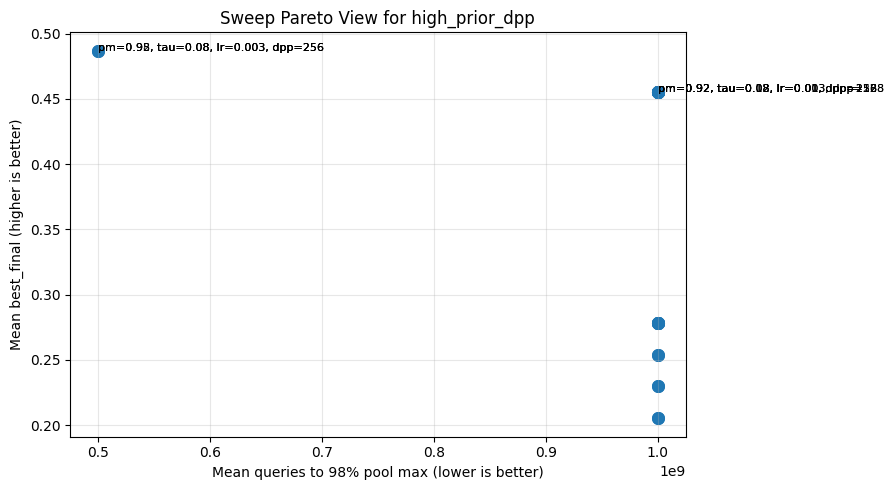

Best hyperparameters from sweep:
{'prior_mean': 0.92, 'tau': 0.08, 'lr': 0.003, 'dpp_candidates': 256.0}


BenchmarkConfig(seed=123, pool_size=2500, seed_size=64, rounds=15, batch_k=32, train_epochs=25, train_batch_size=8192, lr=0.003, hidden_dim=384, depth=5, dropout=0.1, prior_mean=0.92, shortlist_size=5000, dpp_candidates=256.0, tau=0.08, ucb_beta=3.0, ucb_mc_passes=16, pred_batch_size=8192, use_amp=True, use_tf32=True, cache_graphs_on_device=True, auto_tune_cuda_batch_sizes=False, ucb_uncertainty_collapse_eps=1e-06, flat_score_std_eps=1e-06, log_level='INFO')

In [9]:
plt.figure(figsize=(9, 5))
plt.scatter(
    sweep_summary_df["q98_mean"],
    sweep_summary_df["best_final_mean"],
    s=70,
    alpha=0.8,
)

for i, row in sweep_summary_df.head(8).iterrows():
    label = f"pm={row['prior_mean']}, tau={row['tau']}, lr={row['lr']}, dpp={int(row['dpp_candidates'])}"
    plt.annotate(label, (row["q98_mean"], row["best_final_mean"]), fontsize=8)

plt.xlabel("Mean queries to 98% pool max (lower is better)")
plt.ylabel("Mean best_final (higher is better)")
plt.title("Sweep Pareto View for high_prior_dpp")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_hp = sweep_summary_df.iloc[0][param_names].to_dict()
print("Best hyperparameters from sweep:")
print(best_hp)

best_cfg = _clone_cfg(cfg, **best_hp)
best_cfg

In [ ]:
# Optional: run a full-budget benchmark with the best sweep hyperparameters.
# Uncomment to execute.
# full_cfg = _clone_cfg(cfg, **best_hp)
# full_out = drd2_maxfinding_benchmark.run_benchmark(full_cfg)
# full_results = full_out["results"]
# full_pool_max = float(np.max(full_out["scores"]))
#
# full_rows = []
# for r in full_results:
#     full_rows.append({
#         "method": r.method,
#         "final_queries": r.queries[-1],
#         "best_final": r.best_so_far[-1],
#         "simple_regret_final": r.simple_regret[-1],
#         "queries_to_95pct_pool_max": r.threshold_q95,
#         "queries_to_98pct_pool_max": r.threshold_q98,
#     })
# pd.DataFrame(full_rows).sort_values("method").reset_index(drop=True)

## Follow-up Sweep: Larger Query Budget + Lower LR + Weight Decay

This experiment checks the hypothesis directly:

- larger queried set (more rounds and larger batch)
- lower learning rates
- non-zero weight decay
- repeated seeds
- direct comparison against `random`

We keep acquisition-related settings fixed to the previously best values and only vary optimizer regularization settings.

In [4]:
from itertools import product
import importlib

import drd2_maxfinding_benchmark
importlib.reload(drd2_maxfinding_benchmark)


def _clone_cfg2(base_cfg, **updates):
    c = drd2_maxfinding_benchmark.BenchmarkConfig(**vars(base_cfg))
    for k, v in updates.items():
        setattr(c, k, v)
    return c


def _extract_method2(results, method_name):
    for r in results:
        if r.method == method_name:
            return r
    raise ValueError(f"Method not found: {method_name}")


# Use notebook cfg if available, otherwise create a matching default.
if "cfg" in globals():
    cfg_base2 = _clone_cfg2(cfg)
else:
    cfg_base2 = drd2_maxfinding_benchmark.BenchmarkConfig(
        seed=123,
        pool_size=2500,
        seed_size=64,
        rounds=15,
        batch_k=32,
        train_epochs=25,
        train_batch_size=8192,
        hidden_dim=384,
        depth=5,
        shortlist_size=5000,
        dpp_candidates=256,
        tau=0.08,
        ucb_beta=3.0,
        ucb_mc_passes=16,
        pred_batch_size=8192,
        use_amp=True,
        use_tf32=True,
        cache_graphs_on_device=True,
        auto_tune_cuda_batch_sizes=False,
        prior_mean=0.98,
        lr=1e-2,
    )

# Bigger queried set than previous fast sweep.
FOLLOWUP_BASE = {
    "pool_size": min(cfg_base2.pool_size, 2000),
    "rounds": max(cfg_base2.rounds, 22),
    "batch_k": max(cfg_base2.batch_k, 48),
    "train_epochs": min(cfg_base2.train_epochs, 20),
    "auto_tune_cuda_batch_sizes": False,
    # Fix acquisition settings to the best from prior sweep.
    "prior_mean": 0.92,
    "tau": 0.08,
    "dpp_candidates": 256,
}

FOLLOWUP_GRID = {
    "lr": [5e-4, 1e-3, 3e-3],
    "weight_decay": [0.0, 1e-6, 1e-5, 1e-4],
}

FOLLOWUP_SEEDS = [101, 123, 321, 777, 2024]

followup_param_names = list(FOLLOWUP_GRID.keys())
followup_param_combos = [
    dict(zip(followup_param_names, vals))
    for vals in product(*(FOLLOWUP_GRID[p] for p in followup_param_names))
]

print(f"Follow-up combos: {len(followup_param_combos)}")
print(f"Seeds per combo: {len(FOLLOWUP_SEEDS)}")
print(f"High-prior runs: {len(followup_param_combos) * len(FOLLOWUP_SEEDS)}")
print(f"Random baseline runs: {len(FOLLOWUP_SEEDS)}")

Follow-up combos: 12
Seeds per combo: 5
High-prior runs: 60
Random baseline runs: 5


In [12]:
followup_rows = []
random_by_seed = {}

# Reuse output folder from sweep 1 if already defined.
if "sweep_out_dir" not in globals():
    from pathlib import Path
    sweep_out_dir = Path("sweep_outputs")
    sweep_out_dir.mkdir(parents=True, exist_ok=True)

# Run random once per seed for fair per-seed comparison.
for seed in FOLLOWUP_SEEDS:
    random_cfg = _clone_cfg2(cfg_base2, seed=seed, **FOLLOWUP_BASE)
    random_out = drd2_maxfinding_benchmark.run_benchmark(
        random_cfg,
        methods=["random"],
    )
    random_res = _extract_method2(random_out["results"], "random")
    random_by_seed[seed] = {
        "pool_max": float(np.max(random_out["scores"])),
        "best_final": random_res.best_so_far[-1],
        "simple_regret_final": random_res.simple_regret[-1],
        "q95": random_res.threshold_q95,
        "q98": random_res.threshold_q98,
    }

for combo_i, hp in enumerate(followup_param_combos, start=1):
    print(f"\n=== Follow-up combo {combo_i}/{len(followup_param_combos)}: {hp} ===")
    for seed in FOLLOWUP_SEEDS:
        hp_cfg = _clone_cfg2(cfg_base2, seed=seed, **FOLLOWUP_BASE, **hp)
        hp_out = drd2_maxfinding_benchmark.run_benchmark(
            hp_cfg,
            methods=["high_prior_dpp"],
        )
        hp_res = _extract_method2(hp_out["results"], "high_prior_dpp")
        rand = random_by_seed[seed]

        followup_rows.append({
            **hp,
            "seed": seed,
            "pool_max": rand["pool_max"],
            "hp_best_final": hp_res.best_so_far[-1],
            "rand_best_final": rand["best_final"],
            "hp_simple_regret_final": hp_res.simple_regret[-1],
            "rand_simple_regret_final": rand["simple_regret_final"],
            "hp_q95": hp_res.threshold_q95,
            "rand_q95": rand["q95"],
            "hp_q98": hp_res.threshold_q98,
            "rand_q98": rand["q98"],
            "best_final_gain_vs_random": hp_res.best_so_far[-1] - rand["best_final"],
            "regret_delta_vs_random": hp_res.simple_regret[-1] - rand["simple_regret_final"],
            "beats_random": hp_res.best_so_far[-1] > rand["best_final"],
        })

followup_trial_df = pd.DataFrame(followup_rows)

# Persist follow-up trial-level outputs.
followup_trial_csv = sweep_out_dir / "sweep2_trials.csv"
followup_trial_json = sweep_out_dir / "sweep2_trials.json"
followup_baseline_json = sweep_out_dir / "sweep2_random_by_seed.json"

followup_trial_df.to_csv(followup_trial_csv, index=False)
followup_trial_df.to_json(followup_trial_json, orient="records", indent=2)
pd.DataFrame.from_dict(random_by_seed, orient="index").reset_index(names="seed").to_json(
    followup_baseline_json, orient="records", indent=2
)

print(f"Saved: {followup_trial_csv}")
print(f"Saved: {followup_trial_json}")
print(f"Saved: {followup_baseline_json}")

followup_trial_df.head()

Found local copy...
Loading...
Done!


device=cuda
gpu=NVIDIA GeForce RTX 3060
gpu_tuned train_batch_size=8192 pred_batch_size=8192 amp=True tf32=True


Found local copy...


[random] round=1/22 queried=112 best=0.0931 time=0.4s
[random] round=2/22 queried=160 best=0.0931 time=0.2s
[random] round=3/22 queried=208 best=0.0931 time=0.3s
[random] round=4/22 queried=256 best=0.0931 time=0.4s
[random] round=5/22 queried=304 best=0.0931 time=0.5s
[random] round=6/22 queried=352 best=0.5126 time=0.5s
[random] round=7/22 queried=400 best=0.5126 time=0.6s
[random] round=8/22 queried=448 best=0.5126 time=0.7s
[random] round=9/22 queried=496 best=0.5126 time=0.8s
[random] round=10/22 queried=544 best=0.5126 time=0.8s
[random] round=11/22 queried=592 best=0.5126 time=0.9s
[random] round=12/22 queried=640 best=0.5126 time=1.0s
[random] round=13/22 queried=688 best=0.5126 time=1.1s
[random] round=14/22 queried=736 best=0.5126 time=1.2s
[random] round=15/22 queried=784 best=0.5126 time=1.2s
[random] round=16/22 queried=832 best=0.5126 time=1.3s
[random] round=17/22 queried=880 best=0.5126 time=1.5s
[random] round=18/22 queried=928 best=0.5126 time=1.5s
[random] round=19/2

Found local copy...
Loading...
Done!


...

Found local copy...
Loading...
Done!


[high_prior_dpp] round=22/22 queried=1120 best=0.9290 time=2.1s
device=cuda
gpu=NVIDIA GeForce RTX 3060
gpu_tuned train_batch_size=8192 pred_batch_size=8192 amp=True tf32=True


Found local copy...


[high_prior_dpp] round=1/22 queried=112 best=0.0559 time=0.8s
[high_prior_dpp] round=2/22 queried=160 best=0.0559 time=0.6s
[high_prior_dpp] round=3/22 queried=208 best=0.0559 time=0.7s
[high_prior_dpp] round=4/22 queried=256 best=0.0559 time=0.7s
[high_prior_dpp] round=5/22 queried=304 best=0.0559 time=0.8s
[high_prior_dpp] round=6/22 queried=352 best=0.0769 time=0.9s
[high_prior_dpp] round=7/22 queried=400 best=0.1385 time=1.0s
[high_prior_dpp] round=8/22 queried=448 best=0.1385 time=1.2s
[high_prior_dpp] round=9/22 queried=496 best=0.2462 time=1.2s
[high_prior_dpp] round=10/22 queried=544 best=0.2502 time=1.3s
[high_prior_dpp] round=11/22 queried=592 best=0.2502 time=1.3s
[high_prior_dpp] round=12/22 queried=640 best=0.3552 time=1.4s
[high_prior_dpp] round=13/22 queried=688 best=0.3552 time=1.4s
[high_prior_dpp] round=14/22 queried=736 best=0.3552 time=1.5s
[high_prior_dpp] round=15/22 queried=784 best=0.3552 time=1.6s
[high_prior_dpp] round=16/22 queried=832 best=0.3552 time=1.7s
[

,lr,weight_decay,seed,pool_max,hp_best_final,rand_best_final,hp_simple_regret_final,rand_simple_regret_final,hp_q95,rand_q95,hp_q98,rand_q98,best_final_gain_vs_random,regret_delta_vs_random,beats_random
0,0.0005,0.0,101,0.757197,0.757197,0.686520,0.000000,0.070677,256.0,NaN,256.0,NaN,0.070677,-0.070677,True
1,0.0005,0.0,123,0.955461,0.580696,0.955461,0.374765,0.000000,NaN,544.0,NaN,544.0,-0.374765,0.374765,False
2,0.0005,0.0,321,0.666174,0.666174,0.437680,0.000000,0.228494,496.0,NaN,496.0,NaN,0.228494,-0.228494,True
3,0.0005,0.0,777,0.928991,0.928991,0.255822,0.000000,0.673170,160.0,NaN,160.0,NaN,0.673170,-0.673170,True
4,0.0005,0.0,2024,0.829911,0.589170,0.829911,0.240741,0.000000,NaN,976.0,NaN,976.0,-0.240741,0.240741,False


In [13]:
tmp = followup_trial_df.copy()
tmp["hp_q95_pen"] = tmp["hp_q95"].fillna(10**9)
tmp["rand_q95_pen"] = tmp["rand_q95"].fillna(10**9)
tmp["hp_q98_pen"] = tmp["hp_q98"].fillna(10**9)
tmp["rand_q98_pen"] = tmp["rand_q98"].fillna(10**9)

followup_summary_df = (
    tmp.groupby(followup_param_names, as_index=False)
    .agg(
        seeds=("seed", "count"),
        hp_best_final_mean=("hp_best_final", "mean"),
        rand_best_final_mean=("rand_best_final", "mean"),
        gain_vs_random_mean=("best_final_gain_vs_random", "mean"),
        gain_vs_random_std=("best_final_gain_vs_random", "std"),
        beat_rate=("beats_random", "mean"),
        hp_regret_mean=("hp_simple_regret_final", "mean"),
        rand_regret_mean=("rand_simple_regret_final", "mean"),
        regret_delta_mean=("regret_delta_vs_random", "mean"),
        hp_q95_mean=("hp_q95_pen", "mean"),
        rand_q95_mean=("rand_q95_pen", "mean"),
        hp_q98_mean=("hp_q98_pen", "mean"),
        rand_q98_mean=("rand_q98_pen", "mean"),
    )
    .sort_values(
        ["gain_vs_random_mean", "beat_rate", "hp_regret_mean"],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

# Persist follow-up summary outputs.
followup_summary_csv = sweep_out_dir / "sweep2_summary.csv"
followup_summary_json = sweep_out_dir / "sweep2_summary.json"
followup_summary_df.to_csv(followup_summary_csv, index=False)
followup_summary_df.to_json(followup_summary_json, orient="records", indent=2)
print(f"Saved: {followup_summary_csv}")
print(f"Saved: {followup_summary_json}")

followup_summary_df.head(12)

Saved: sweep_outputs/sweep2_summary.csv
Saved: sweep_outputs/sweep2_summary.json


,lr,weight_decay,seeds,hp_best_final_mean,rand_best_final_mean,gain_vs_random_mean,gain_vs_random_std,beat_rate,hp_regret_mean,rand_regret_mean,regret_delta_mean,hp_q95_mean,rand_q95_mean,hp_q98_mean,rand_q98_mean
0,0.0005,0.000100,5,0.779399,0.633079,0.146320,0.339585,0.6,0.048148,0.194468,-0.146320,200000454.4,600000304.0,200000454.4,600000304.0
1,0.0010,0.000100,5,0.779399,0.633079,0.146320,0.339585,0.6,0.048148,0.194468,-0.146320,200000416.0,600000304.0,200000416.0,600000304.0
2,0.0010,0.000001,5,0.752594,0.633079,0.119515,0.380589,0.6,0.074953,0.194468,-0.119515,200000492.8,600000304.0,200000492.8,600000304.0
3,0.0005,0.000001,5,0.706877,0.633079,0.073799,0.377945,0.4,0.120669,0.194468,-0.073799,400000384.0,600000304.0,400000384.0,600000304.0
4,0.0005,0.000000,5,0.704445,0.633079,0.071367,0.413310,0.6,0.123101,0.194468,-0.071367,400000182.4,600000304.0,400000182.4,600000304.0
5,0.0005,0.000010,5,0.704445,0.633079,0.071367,0.413310,0.6,0.123101,0.194468,-0.071367,400000326.4,600000304.0,400000326.4,600000304.0
6,0.0010,0.000010,5,0.704445,0.633079,0.071367,0.413310,0.6,0.123101,0.194468,-0.071367,400000336.0,600000304.0,400000336.0,600000304.0
7,0.0030,0.000000,5,0.704445,0.633079,0.071367,0.413310,0.6,0.123101,0.194468,-0.071367,400000393.6,600000304.0,400000393.6,600000304.0
8,0.0010,0.000000,5,0.658729,0.633079,0.025650,0.404125,0.4,0.168818,0.194468,-0.025650,600000169.6,600000304.0,600000169.6,600000304.0
9,0.0030,0.000001,5,0.658729,0.633079,0.025650,0.404125,0.4,0.168818,0.194468,-0.025650,600000188.8,600000304.0,600000188.8,600000304.0


## Robust V2 Sweeps (Implemented Suggestions)

This section runs and saves four additional experiment blocks:

1. `robust_validation`: top optimizer settings vs random over more seeds
2. `optimizer_refine`: narrow learning-rate/weight-decay sweep
3. `acq_refine`: tau and dpp_candidates refinement
4. `capacity_check`: hidden_dim/depth sanity check

All outputs are persisted under `sweep_outputs_v3/` as CSV and JSON.

In [4]:
from itertools import product
from pathlib import Path
import json
import importlib

import numpy as np
import pandas as pd
import drd2_maxfinding_benchmark
importlib.reload(drd2_maxfinding_benchmark)


def _clone_cfg_v3(base_cfg, **updates):
    c = drd2_maxfinding_benchmark.BenchmarkConfig(**vars(base_cfg))
    for k, v in updates.items():
        setattr(c, k, v)
    return c


def _extract_method_v3(results, method_name):
    for r in results:
        if r.method == method_name:
            return r
    raise ValueError(f"Method not found: {method_name}")


def _ci95_half_width(x):
    arr = np.asarray(x, dtype=float)
    if arr.size <= 1:
        return float("nan")
    return 1.96 * float(np.std(arr, ddof=1) / np.sqrt(arr.size))


def run_sweep_block(
    name,
    cfg_base,
    seeds,
    fixed_params,
    grid,
    out_dir,
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    param_names = list(grid.keys())
    param_combos = [
        dict(zip(param_names, vals))
        for vals in product(*(grid[p] for p in param_names))
    ]

    print(f"\n[{name}] combos={len(param_combos)} seeds={len(seeds)}")

    # Random baseline once per seed.
    random_by_seed = {}
    for seed in seeds:
        base_cfg = _clone_cfg_v3(cfg_base, seed=seed, **fixed_params)
        out = drd2_maxfinding_benchmark.run_benchmark(base_cfg, methods=["random"])
        rr = _extract_method_v3(out["results"], "random")
        random_by_seed[seed] = {
            "pool_max": float(np.max(out["scores"])),
            "best_final": rr.best_so_far[-1],
            "simple_regret_final": rr.simple_regret[-1],
            "q95": rr.threshold_q95,
            "q98": rr.threshold_q98,
        }

    rows = []
    for combo_i, hp in enumerate(param_combos, start=1):
        print(f"[{name}] combo {combo_i}/{len(param_combos)}: {hp}")
        for seed in seeds:
            run_cfg = _clone_cfg_v3(cfg_base, seed=seed, **fixed_params, **hp)
            out = drd2_maxfinding_benchmark.run_benchmark(run_cfg, methods=["high_prior_dpp"])
            hr = _extract_method_v3(out["results"], "high_prior_dpp")
            rb = random_by_seed[seed]
            rows.append({
                **hp,
                "seed": seed,
                "pool_max": rb["pool_max"],
                "hp_best_final": hr.best_so_far[-1],
                "rand_best_final": rb["best_final"],
                "hp_simple_regret_final": hr.simple_regret[-1],
                "rand_simple_regret_final": rb["simple_regret_final"],
                "hp_q95": hr.threshold_q95,
                "rand_q95": rb["q95"],
                "hp_q98": hr.threshold_q98,
                "rand_q98": rb["q98"],
                "best_final_gain_vs_random": hr.best_so_far[-1] - rb["best_final"],
                "regret_delta_vs_random": hr.simple_regret[-1] - rb["simple_regret_final"],
                "beats_random": hr.best_so_far[-1] > rb["best_final"],
            })

    trial_df = pd.DataFrame(rows)

    summary_df = (
        trial_df.groupby(param_names, as_index=False)
        .agg(
            seeds=("seed", "count"),
            hp_best_final_mean=("hp_best_final", "mean"),
            rand_best_final_mean=("rand_best_final", "mean"),
            gain_vs_random_mean=("best_final_gain_vs_random", "mean"),
            gain_vs_random_std=("best_final_gain_vs_random", "std"),
            beat_rate=("beats_random", "mean"),
            hp_regret_mean=("hp_simple_regret_final", "mean"),
            rand_regret_mean=("rand_simple_regret_final", "mean"),
            regret_delta_mean=("regret_delta_vs_random", "mean"),
            hp_q95_hit_rate=("hp_q95", lambda s: float(s.notna().mean())),
            rand_q95_hit_rate=("rand_q95", lambda s: float(s.notna().mean())),
            hp_q98_hit_rate=("hp_q98", lambda s: float(s.notna().mean())),
            rand_q98_hit_rate=("rand_q98", lambda s: float(s.notna().mean())),
            hp_q95_mean_when_hit=("hp_q95", lambda s: float(s.dropna().mean()) if s.notna().any() else float("nan")),
            rand_q95_mean_when_hit=("rand_q95", lambda s: float(s.dropna().mean()) if s.notna().any() else float("nan")),
        )
        .sort_values(["gain_vs_random_mean", "beat_rate"], ascending=[False, False])
        .reset_index(drop=True)
    )

    ci_df = (
        trial_df.groupby(param_names, as_index=False)
        .agg(
            gain_ci95_half=("best_final_gain_vs_random", _ci95_half_width),
            gain_median=("best_final_gain_vs_random", "median"),
        )
    )
    summary_df = summary_df.merge(ci_df, on=param_names, how="left")
    summary_df["gain_ci95_lower"] = summary_df["gain_vs_random_mean"] - summary_df["gain_ci95_half"]

    prefix = out_dir / name
    trial_df.to_csv(f"{prefix}_trials.csv", index=False)
    trial_df.to_json(f"{prefix}_trials.json", orient="records", indent=2)
    summary_df.to_csv(f"{prefix}_summary.csv", index=False)
    summary_df.to_json(f"{prefix}_summary.json", orient="records", indent=2)
    pd.DataFrame.from_dict(random_by_seed, orient="index").reset_index(names="seed").to_json(
        f"{prefix}_random_by_seed.json", orient="records", indent=2
    )

    return trial_df, summary_df


v3_out_dir = Path("sweep_outputs_v3")
v3_out_dir.mkdir(parents=True, exist_ok=True)

# Ensure cfg is available in kernel.
if "cfg" not in globals():
    cfg = drd2_maxfinding_benchmark.BenchmarkConfig(
        seed=123,
        pool_size=2500,
        seed_size=64,
        rounds=15,
        batch_k=32,
        train_epochs=25,
        train_batch_size=8192,
        hidden_dim=384,
        depth=5,
        shortlist_size=5000,
        dpp_candidates=256,
        tau=0.08,
        ucb_beta=3.0,
        ucb_mc_passes=16,
        pred_batch_size=8192,
        use_amp=True,
        use_tf32=True,
        cache_graphs_on_device=True,
        auto_tune_cuda_batch_sizes=False,
        prior_mean=0.98,
        lr=1e-2,
    )

BASE_V3 = {
    "pool_size": min(cfg.pool_size, 2000),
    "rounds": max(cfg.rounds, 18),
    "batch_k": max(cfg.batch_k, 48),
    "train_epochs": min(cfg.train_epochs, 20),
    "auto_tune_cuda_batch_sizes": False,
    "prior_mean": 0.92,
    "tau": 0.08,
    "dpp_candidates": 256,
}

print("V3 setup ready.")

V3 setup ready.


In [5]:
# 1) Robust validation across more seeds for top optimizer settings.
ROBUST_SEEDS = [11, 47, 101, 123, 187, 321, 555, 777, 999, 2024]
ROBUST_GRID = {
    "lr": [5e-4, 1e-3],
    "weight_decay": [1e-4],
}

robust_trials, robust_summary = run_sweep_block(
    name="robust_validation",
    cfg_base=cfg,
    seeds=ROBUST_SEEDS,
    fixed_params=BASE_V3,
    grid=ROBUST_GRID,
    out_dir=v3_out_dir,
)

robust_summary.head(10)

Found local copy...
Loading...


Done!



[robust_validation] combos=2 seeds=10
device=cuda
gpu=NVIDIA GeForce RTX 3060
gpu_tuned train_batch_size=8192 pred_batch_size=8192 amp=True tf32=True


Found local copy...


[random] round=1/18 queried=112 best=0.5472 time=0.4s
[random] round=2/18 queried=160 best=0.5472 time=0.2s
[random] round=3/18 queried=208 best=0.5472 time=0.3s
[random] round=4/18 queried=256 best=0.5472 time=0.4s
[random] round=5/18 queried=304 best=0.5472 time=0.4s
[random] round=6/18 queried=352 best=0.5472 time=0.5s
[random] round=7/18 queried=400 best=0.5472 time=0.6s
[random] round=8/18 queried=448 best=0.5472 time=0.6s
[random] round=9/18 queried=496 best=0.5472 time=0.7s
[random] round=10/18 queried=544 best=0.5472 time=0.8s
[random] round=11/18 queried=592 best=0.5472 time=0.9s
[random] round=12/18 queried=640 best=0.5472 time=1.0s
[random] round=13/18 queried=688 best=0.5472 time=1.1s
[random] round=14/18 queried=736 best=0.5472 time=1.2s
[random] round=15/18 queried=784 best=0.5472 time=1.3s
[random] round=16/18 queried=832 best=0.5912 time=1.3s
[random] round=17/18 queried=880 best=0.5912 time=1.4s


...

Found local copy...
Loading...
Done!


[high_prior_dpp] round=18/18 queried=928 best=0.9701 time=1.7s
device=cuda
gpu=NVIDIA GeForce RTX 3060
gpu_tuned train_batch_size=8192 pred_batch_size=8192 amp=True tf32=True


Found local copy...


[high_prior_dpp] round=1/18 queried=112 best=0.0559 time=1.0s
[high_prior_dpp] round=2/18 queried=160 best=0.0635 time=0.6s
[high_prior_dpp] round=3/18 queried=208 best=0.0635 time=0.6s
[high_prior_dpp] round=4/18 queried=256 best=0.2462 time=0.7s
[high_prior_dpp] round=5/18 queried=304 best=0.2462 time=0.8s
[high_prior_dpp] round=6/18 queried=352 best=0.2462 time=0.8s
[high_prior_dpp] round=7/18 queried=400 best=0.2462 time=0.9s
[high_prior_dpp] round=8/18 queried=448 best=0.2462 time=1.0s
[high_prior_dpp] round=9/18 queried=496 best=0.2502 time=1.1s
[high_prior_dpp] round=10/18 queried=544 best=0.2502 time=1.2s
[high_prior_dpp] round=11/18 queried=592 best=0.2502 time=1.2s
[high_prior_dpp] round=12/18 queried=640 best=0.3552 time=1.3s
[high_prior_dpp] round=13/18 queried=688 best=0.3552 time=1.3s
[high_prior_dpp] round=14/18 queried=736 best=0.3552 time=1.4s
[high_prior_dpp] round=15/18 queried=784 best=0.3552 time=1.5s
[high_prior_dpp] round=16/18 queried=832 best=0.5892 time=1.6s
[

,lr,weight_decay,seeds,hp_best_final_mean,rand_best_final_mean,gain_vs_random_mean,gain_vs_random_std,beat_rate,hp_regret_mean,rand_regret_mean,regret_delta_mean,hp_q95_hit_rate,rand_q95_hit_rate,hp_q98_hit_rate,rand_q98_hit_rate,hp_q95_mean_when_hit,rand_q95_mean_when_hit,gain_ci95_half,gain_median,gain_ci95_lower
0,0.0010,0.0001,10,0.741978,0.581584,0.160394,0.231535,0.5,0.035292,0.195686,-0.160394,0.8,0.5,0.8,0.5,568.0,505.6,0.143507,0.116961,0.016888
1,0.0005,0.0001,10,0.683561,0.581584,0.101978,0.274816,0.4,0.093708,0.195686,-0.101978,0.6,0.5,0.6,0.5,400.0,505.6,0.170333,0.000000,-0.068355


In [5]:
# 2) Narrow optimizer refinement around best region.
OPT_SEEDS = [101, 123, 321, 777, 2024]
OPT_GRID = {
    "lr": [7e-4, 1e-3, 1.5e-3],
    "weight_decay": [3e-5, 1e-4, 3e-4],
}

opt_trials, opt_summary = run_sweep_block(
    name="optimizer_refine",
    cfg_base=cfg,
    seeds=OPT_SEEDS,
    fixed_params=BASE_V3,
    grid=OPT_GRID,
    out_dir=v3_out_dir,
)

opt_summary.head(12)

Found local copy...
Loading...
Done!



[optimizer_refine] combos=9 seeds=5
device=cuda
gpu=NVIDIA GeForce RTX 3060
gpu_tuned train_batch_size=8192 pred_batch_size=8192 amp=True tf32=True


Found local copy...


[random] round=1/18 queried=112 best=0.0931 time=0.3s
[random] round=2/18 queried=160 best=0.0931 time=0.3s
[random] round=3/18 queried=208 best=0.0931 time=0.3s
[random] round=4/18 queried=256 best=0.0931 time=0.4s
[random] round=5/18 queried=304 best=0.0931 time=0.5s
[random] round=6/18 queried=352 best=0.5126 time=0.6s
[random] round=7/18 queried=400 best=0.5126 time=0.6s
[random] round=8/18 queried=448 best=0.5126 time=0.7s
[random] round=9/18 queried=496 best=0.5126 time=0.8s
[random] round=10/18 queried=544 best=0.5126 time=0.9s
[random] round=11/18 queried=592 best=0.5126 time=0.9s
[random] round=12/18 queried=640 best=0.5126 time=1.0s
[random] round=13/18 queried=688 best=0.5126 time=1.1s
[random] round=14/18 queried=736 best=0.5126 time=1.2s
[random] round=15/18 queried=784 best=0.5126 time=1.2s
[random] round=16/18 queried=832 best=0.5126 time=1.3s
[random] round=17/18 queried=880 best=0.5126 time=1.4s


Found local copy...
Loading...
Done!


...

Found local copy...
Loading...
Done!


[high_prior_dpp] round=18/18 queried=928 best=0.9290 time=2.4s
device=cuda
gpu=NVIDIA GeForce RTX 3060
gpu_tuned train_batch_size=8192 pred_batch_size=8192 amp=True tf32=True


Found local copy...


[high_prior_dpp] round=1/18 queried=112 best=0.0559 time=0.8s
[high_prior_dpp] round=2/18 queried=160 best=0.0559 time=0.6s
[high_prior_dpp] round=3/18 queried=208 best=0.0761 time=0.7s
[high_prior_dpp] round=4/18 queried=256 best=0.3552 time=0.7s
[high_prior_dpp] round=5/18 queried=304 best=0.3552 time=0.8s
[high_prior_dpp] round=6/18 queried=352 best=0.3552 time=0.9s
[high_prior_dpp] round=7/18 queried=400 best=0.3552 time=1.0s
[high_prior_dpp] round=8/18 queried=448 best=0.3552 time=1.0s
[high_prior_dpp] round=9/18 queried=496 best=0.3552 time=1.1s
[high_prior_dpp] round=10/18 queried=544 best=0.3552 time=1.1s
[high_prior_dpp] round=11/18 queried=592 best=0.5892 time=1.2s
[high_prior_dpp] round=12/18 queried=640 best=0.5892 time=1.3s
[high_prior_dpp] round=13/18 queried=688 best=0.5892 time=1.3s
[high_prior_dpp] round=14/18 queried=736 best=0.5892 time=1.5s
[high_prior_dpp] round=15/18 queried=784 best=0.5892 time=1.6s
[high_prior_dpp] round=16/18 queried=832 best=0.5892 time=1.7s
[

,lr,weight_decay,seeds,hp_best_final_mean,rand_best_final_mean,gain_vs_random_mean,gain_vs_random_std,beat_rate,hp_regret_mean,rand_regret_mean,regret_delta_mean,hp_q95_hit_rate,rand_q95_hit_rate,hp_q98_hit_rate,rand_q98_hit_rate,hp_q95_mean_when_hit,rand_q95_mean_when_hit,gain_ci95_half,gain_median,gain_ci95_lower
0,0.0010,0.00010,5,0.779399,0.49442,0.284978,0.243042,0.8,0.048148,0.333126,-0.284978,0.8,0.2,0.8,0.2,520.0,544.0,0.213036,0.244644,0.071942
1,0.0007,0.00003,5,0.704445,0.49442,0.210025,0.374913,0.8,0.123101,0.333126,-0.210025,0.6,0.2,0.6,0.2,464.0,544.0,0.328625,0.244644,-0.118600
2,0.0007,0.00010,5,0.704445,0.49442,0.210025,0.374913,0.8,0.123101,0.333126,-0.210025,0.6,0.2,0.6,0.2,464.0,544.0,0.328625,0.244644,-0.118600
3,0.0010,0.00003,5,0.704445,0.49442,0.210025,0.374913,0.8,0.123101,0.333126,-0.210025,0.6,0.2,0.6,0.2,432.0,544.0,0.328625,0.244644,-0.118600
4,0.0010,0.00030,5,0.681613,0.49442,0.187193,0.339959,0.8,0.145934,0.333126,-0.187193,0.4,0.2,0.4,0.2,568.0,544.0,0.297988,0.233922,-0.110795
5,0.0007,0.00030,5,0.658729,0.49442,0.164309,0.379202,0.8,0.168818,0.333126,-0.164309,0.4,0.2,0.4,0.2,472.0,544.0,0.332385,0.233922,-0.168077
6,0.0015,0.00003,5,0.658729,0.49442,0.164309,0.379202,0.8,0.168818,0.333126,-0.164309,0.4,0.2,0.4,0.2,496.0,544.0,0.332385,0.233922,-0.168077
7,0.0015,0.00010,5,0.658729,0.49442,0.164309,0.379202,0.8,0.168818,0.333126,-0.164309,0.4,0.2,0.4,0.2,496.0,544.0,0.332385,0.233922,-0.168077
8,0.0015,0.00030,5,0.658729,0.49442,0.164309,0.379202,0.8,0.168818,0.333126,-0.164309,0.4,0.2,0.4,0.2,448.0,544.0,0.332385,0.233922,-0.168077


In [11]:
# Consolidated analysis report persisted to disk.
summary_files = {
    "robust_validation": "robust_validation_summary.csv",
    "optimizer_refine": "optimizer_refine_summary.csv",
    "acq_refine": "acq_refine_summary.csv",
    "capacity_check": "capacity_check_summary.csv",
}

report = {}
for name, fn in summary_files.items():
    df = pd.read_csv(v3_out_dir / fn)
    top = df.sort_values("gain_vs_random_mean", ascending=False).iloc[0].to_dict()
    report[name] = {
        "num_rows": int(len(df)),
        "top": top,
    }

report_path_json = v3_out_dir / "v3_analysis_report.json"
report_path_txt = v3_out_dir / "v3_analysis_report.txt"

with open(report_path_json, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

lines = []
for name, payload in report.items():
    t = payload["top"]
    lines.append(f"[{name}]")
    lines.append(f"rows={payload['num_rows']}")
    lines.append(f"gain_vs_random_mean={t['gain_vs_random_mean']:.6f}")
    lines.append(f"gain_ci95_lower={t.get('gain_ci95_lower', float('nan')):.6f}")
    lines.append(f"beat_rate={t['beat_rate']:.3f}")
    lines.append(f"hp_best_final_mean={t['hp_best_final_mean']:.6f}")
    lines.append(f"rand_best_final_mean={t['rand_best_final_mean']:.6f}")
    lines.append("")

with open(report_path_txt, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print(f"Saved: {report_path_json}")
print(f"Saved: {report_path_txt}")
pd.DataFrame(report).T

Saved: sweep_outputs_v3/v3_analysis_report.json
Saved: sweep_outputs_v3/v3_analysis_report.txt


,num_rows,top
robust_validation,2,"{'lr': 0.001, 'weight_decay': 0.0001, 'seeds':..."
optimizer_refine,9,"{'lr': 0.001, 'weight_decay': 0.0001, 'seeds':..."
acq_refine,6,"{'tau': 0.08, 'dpp_candidates': 256.0, 'seeds'..."
capacity_check,4,"{'hidden_dim': 384.0, 'depth': 5.0, 'seeds': 5..."


In [7]:
# 4) Capacity sanity check at fixed optimizer/acquisition settings.
CAP_SEEDS = [101, 123, 321, 777, 2024]
CAP_FIXED = dict(BASE_V3)
CAP_FIXED.update({"lr": 1e-3, "weight_decay": 1e-4, "tau": 0.08, "dpp_candidates": 256})
CAP_GRID = {
    "hidden_dim": [384, 512],
    "depth": [5, 6],
}

cap_trials, cap_summary = run_sweep_block(
    name="capacity_check",
    cfg_base=cfg,
    seeds=CAP_SEEDS,
    fixed_params=CAP_FIXED,
    grid=CAP_GRID,
    out_dir=v3_out_dir,
)

cap_summary.head(10)

Found local copy...
Loading...



[capacity_check] combos=4 seeds=5
device=cuda
gpu=NVIDIA GeForce RTX 3060
gpu_tuned train_batch_size=8192 pred_batch_size=8192 amp=True tf32=True


Done!
Found local copy...


[random] round=1/18 queried=112 best=0.0931 time=0.3s
[random] round=2/18 queried=160 best=0.0931 time=0.2s
[random] round=3/18 queried=208 best=0.0931 time=0.3s
[random] round=4/18 queried=256 best=0.0931 time=0.4s
[random] round=5/18 queried=304 best=0.0931 time=0.4s
[random] round=6/18 queried=352 best=0.5126 time=0.5s
[random] round=7/18 queried=400 best=0.5126 time=0.6s
[random] round=8/18 queried=448 best=0.5126 time=0.7s
[random] round=9/18 queried=496 best=0.5126 time=0.7s
[random] round=10/18 queried=544 best=0.5126 time=0.8s
[random] round=11/18 queried=592 best=0.5126 time=0.9s
[random] round=12/18 queried=640 best=0.5126 time=1.0s
[random] round=13/18 queried=688 best=0.5126 time=1.0s
[random] round=14/18 queried=736 best=0.5126 time=1.1s
[random] round=15/18 queried=784 best=0.5126 time=1.2s
[random] round=16/18 queried=832 best=0.5126 time=1.2s
[random] round=17/18 queried=880 best=0.5126 time=1.3s


Found local copy...
Loading...
Done!


...

Found local copy...
Loading...
Done!


[high_prior_dpp] round=18/18 queried=928 best=0.9290 time=2.4s
device=cuda
gpu=NVIDIA GeForce RTX 3060
gpu_tuned train_batch_size=8192 pred_batch_size=8192 amp=True tf32=True


Found local copy...


[high_prior_dpp] round=1/18 queried=112 best=0.0559 time=0.8s
[high_prior_dpp] round=2/18 queried=160 best=0.0559 time=0.7s
[high_prior_dpp] round=3/18 queried=208 best=0.1377 time=0.8s
[high_prior_dpp] round=4/18 queried=256 best=0.1377 time=1.0s
[high_prior_dpp] round=5/18 queried=304 best=0.3552 time=2.3s
[high_prior_dpp] round=6/18 queried=352 best=0.3552 time=1.2s
[high_prior_dpp] round=7/18 queried=400 best=0.3552 time=1.2s
[high_prior_dpp] round=8/18 queried=448 best=0.3552 time=1.4s
[high_prior_dpp] round=9/18 queried=496 best=0.3552 time=1.5s
[high_prior_dpp] round=10/18 queried=544 best=0.3552 time=1.6s
[high_prior_dpp] round=11/18 queried=592 best=0.3552 time=1.5s
[high_prior_dpp] round=12/18 queried=640 best=0.3552 time=1.7s
[high_prior_dpp] round=13/18 queried=688 best=0.3552 time=1.7s
[high_prior_dpp] round=14/18 queried=736 best=0.5892 time=2.0s
[high_prior_dpp] round=15/18 queried=784 best=0.5892 time=2.0s
[high_prior_dpp] round=16/18 queried=832 best=0.5892 time=2.2s
[

,hidden_dim,depth,seeds,hp_best_final_mean,rand_best_final_mean,gain_vs_random_mean,gain_vs_random_std,beat_rate,hp_regret_mean,rand_regret_mean,regret_delta_mean,hp_q95_hit_rate,rand_q95_hit_rate,hp_q98_hit_rate,rand_q98_hit_rate,hp_q95_mean_when_hit,rand_q95_mean_when_hit,gain_ci95_half,gain_median,gain_ci95_lower
0,384,5,5,0.779399,0.49442,0.284978,0.243042,0.8,0.048148,0.333126,-0.284978,0.8,0.2,0.8,0.2,520.0,544.0,0.213036,0.244644,0.071942
1,384,6,5,0.658729,0.49442,0.164309,0.379202,0.8,0.168818,0.333126,-0.164309,0.4,0.2,0.4,0.2,280.0,544.0,0.332385,0.233922,-0.168077
2,512,5,5,0.658729,0.49442,0.164309,0.379202,0.8,0.168818,0.333126,-0.164309,0.4,0.2,0.4,0.2,304.0,544.0,0.332385,0.233922,-0.168077
3,512,6,5,0.658729,0.49442,0.164309,0.379202,0.8,0.168818,0.333126,-0.164309,0.4,0.2,0.4,0.2,400.0,544.0,0.332385,0.233922,-0.168077


In [9]:
# 3) Acquisition refinement at fixed optimizer.
ACQ_SEEDS = [101, 123, 321, 777, 2024]
ACQ_FIXED = dict(BASE_V3)
# Remove keys that are explicitly swept in ACQ_GRID.
ACQ_FIXED.pop("tau", None)
ACQ_FIXED.pop("dpp_candidates", None)
ACQ_FIXED.update({"lr": 1e-3, "weight_decay": 1e-4})
ACQ_GRID = {
    "tau": [0.06, 0.08, 0.10],
    "dpp_candidates": [256, 384],
}

acq_trials, acq_summary = run_sweep_block(
    name="acq_refine",
    cfg_base=cfg,
    seeds=ACQ_SEEDS,
    fixed_params=ACQ_FIXED,
    grid=ACQ_GRID,
    out_dir=v3_out_dir,
)

acq_summary.head(12)

Found local copy...
Loading...
Done!



[acq_refine] combos=6 seeds=5
device=cuda
gpu=NVIDIA GeForce RTX 3060
gpu_tuned train_batch_size=8192 pred_batch_size=8192 amp=True tf32=True


Found local copy...


[random] round=1/18 queried=112 best=0.0931 time=0.4s
[random] round=2/18 queried=160 best=0.0931 time=0.2s
[random] round=3/18 queried=208 best=0.0931 time=0.3s
[random] round=4/18 queried=256 best=0.0931 time=0.4s
[random] round=5/18 queried=304 best=0.0931 time=0.4s
[random] round=6/18 queried=352 best=0.5126 time=0.5s
[random] round=7/18 queried=400 best=0.5126 time=0.6s
[random] round=8/18 queried=448 best=0.5126 time=0.7s
[random] round=9/18 queried=496 best=0.5126 time=0.7s
[random] round=10/18 queried=544 best=0.5126 time=0.8s
[random] round=11/18 queried=592 best=0.5126 time=0.9s
[random] round=12/18 queried=640 best=0.5126 time=0.9s
[random] round=13/18 queried=688 best=0.5126 time=2.2s
[random] round=14/18 queried=736 best=0.5126 time=1.1s
[random] round=15/18 queried=784 best=0.5126 time=1.2s
[random] round=16/18 queried=832 best=0.5126 time=1.3s
[random] round=17/18 queried=880 best=0.5126 time=1.3s


Found local copy...
Loading...
Done!


...

Found local copy...
Loading...
Done!


[high_prior_dpp] round=18/18 queried=928 best=0.9290 time=2.0s
device=cuda
gpu=NVIDIA GeForce RTX 3060
gpu_tuned train_batch_size=8192 pred_batch_size=8192 amp=True tf32=True


Found local copy...


[high_prior_dpp] round=1/18 queried=112 best=0.0559 time=1.0s
[high_prior_dpp] round=2/18 queried=160 best=0.0559 time=0.8s
[high_prior_dpp] round=3/18 queried=208 best=0.0559 time=0.9s
[high_prior_dpp] round=4/18 queried=256 best=0.2462 time=0.9s
[high_prior_dpp] round=5/18 queried=304 best=0.2462 time=0.9s
[high_prior_dpp] round=6/18 queried=352 best=0.2462 time=1.1s
[high_prior_dpp] round=7/18 queried=400 best=0.3552 time=1.1s
[high_prior_dpp] round=8/18 queried=448 best=0.3552 time=1.3s
[high_prior_dpp] round=9/18 queried=496 best=0.3552 time=1.2s
[high_prior_dpp] round=10/18 queried=544 best=0.3552 time=1.4s
[high_prior_dpp] round=11/18 queried=592 best=0.3552 time=1.4s
[high_prior_dpp] round=12/18 queried=640 best=0.5892 time=1.5s
[high_prior_dpp] round=13/18 queried=688 best=0.5892 time=1.5s
[high_prior_dpp] round=14/18 queried=736 best=0.5892 time=1.7s
[high_prior_dpp] round=15/18 queried=784 best=0.5892 time=1.8s
[high_prior_dpp] round=16/18 queried=832 best=0.5892 time=1.9s
[

,tau,dpp_candidates,seeds,hp_best_final_mean,rand_best_final_mean,gain_vs_random_mean,gain_vs_random_std,beat_rate,hp_regret_mean,rand_regret_mean,regret_delta_mean,hp_q95_hit_rate,rand_q95_hit_rate,hp_q98_hit_rate,rand_q98_hit_rate,hp_q95_mean_when_hit,rand_q95_mean_when_hit,gain_ci95_half,gain_median,gain_ci95_lower
0,0.08,256,5,0.779399,0.49442,0.284978,0.243042,0.8,0.048148,0.333126,-0.284978,0.8,0.2,0.8,0.2,520.0,544.0,0.213036,0.244644,0.071942
1,0.10,384,5,0.727329,0.49442,0.232909,0.331243,0.8,0.100218,0.333126,-0.232909,0.6,0.2,0.6,0.2,528.0,544.0,0.290348,0.244644,-0.057439
2,0.08,384,5,0.706877,0.49442,0.212457,0.404679,0.8,0.120669,0.333126,-0.212457,0.6,0.2,0.6,0.2,544.0,544.0,0.354717,0.244644,-0.142260
3,0.06,384,5,0.704445,0.49442,0.210025,0.374913,0.8,0.123101,0.333126,-0.210025,0.6,0.2,0.6,0.2,416.0,544.0,0.328625,0.244644,-0.118600
4,0.06,256,5,0.658729,0.49442,0.164309,0.379202,0.8,0.168818,0.333126,-0.164309,0.4,0.2,0.4,0.2,328.0,544.0,0.332385,0.233922,-0.168077
5,0.10,256,5,0.658729,0.49442,0.164309,0.379202,0.8,0.168818,0.333126,-0.164309,0.4,0.2,0.4,0.2,376.0,544.0,0.332385,0.233922,-0.168077


In [10]:
# 5) Consolidated report from saved v3 summaries
summary_files = {
    "robust_validation": "robust_validation_summary.csv",
    "optimizer_refine": "optimizer_refine_summary.csv",
    "acq_refine": "acq_refine_summary.csv",
    "capacity_check": "capacity_check_summary.csv",
}

report = {}
for name, fn in summary_files.items():
    df = pd.read_csv(v3_out_dir / fn)
    top = df.sort_values("gain_vs_random_mean", ascending=False).iloc[0].to_dict()
    report[name] = {
        "num_rows": int(len(df)),
        "best_config": {k: float(v) if isinstance(v, (int, float, np.number)) else v for k, v in top.items()},
    }

(report_path_json := v3_out_dir / "v3_analysis_report.json").write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)

lines = ["V3 Sweep Analysis Report", "=" * 28, ""]
for name, payload in report.items():
    lines.append(f"[{name}] rows={payload['num_rows']}")
    best = payload["best_config"]
    lines.append(
        f"  gain_vs_random_mean={best.get('gain_vs_random_mean', float('nan')):.4f} "
        f"beat_rate={best.get('beat_rate', float('nan')):.3f} "
        f"hp_best_final_mean={best.get('hp_best_final_mean', float('nan')):.4f}"
    )
    keys = [
        k
        for k in ("lr", "weight_decay", "tau", "dpp_candidates", "hidden_dim", "depth")
        if k in best
    ]
    if keys:
        cfg_str = ", ".join(f"{k}={best[k]}" for k in keys)
        lines.append(f"  best_config: {cfg_str}")
    lines.append("")

(report_path_txt := v3_out_dir / "v3_analysis_report.txt").write_text(
    "\n".join(lines), encoding="utf-8"
)

print(f"Saved {report_path_json}")
print(f"Saved {report_path_txt}")
report

Saved sweep_outputs_v3/v3_analysis_report.json
Saved sweep_outputs_v3/v3_analysis_report.txt


{'robust_validation': {'num_rows': 2,
  'best_config': {'lr': 0.001,
   'weight_decay': 0.0001,
   'seeds': 10.0,
   'hp_best_final_mean': 0.7419777244329453,
   'rand_best_final_mean': 0.5815836012363433,
   'gain_vs_random_mean': 0.1603941231966018,
   'gain_vs_random_std': 0.2315345572134258,
   'beat_rate': 0.5,
   'hp_regret_mean': 0.0352916657924652,
   'rand_regret_mean': 0.195685788989067,
   'regret_delta_mean': -0.1603941231966018,
   'hp_q95_hit_rate': 0.8,
   'rand_q95_hit_rate': 0.5,
   'hp_q98_hit_rate': 0.8,
   'rand_q98_hit_rate': 0.5,
   'hp_q95_mean_when_hit': 568.0,
   'rand_q95_mean_when_hit': 505.6,
   'gain_ci95_half': 0.1435066053352668,
   'gain_median': 0.1169609874486923,
   'gain_ci95_lower': 0.016887517861335}},
 'optimizer_refine': {'num_rows': 9,
  'best_config': {'lr': 0.001,
   'weight_decay': 0.0001,
   'seeds': 5.0,
   'hp_best_final_mean': 0.7793985486030579,
   'rand_best_final_mean': 0.4944203794002533,
   'gain_vs_random_mean': 0.2849781692028045,


In [4]:
from pathlib import Path

cwd = Path.cwd()
paths = {
    "data": Path("data"),
    "oracle": Path("oracle"),
    "sweep_outputs": Path("sweep_outputs"),
    "sweep_outputs_v3": Path("sweep_outputs_v3"),
}

print(f"cwd: {cwd}")
for name, p in paths.items():
    exists = p.exists()
    kind = "dir" if p.is_dir() else ("file" if p.is_file() else "missing")
    sample = []
    if p.is_dir():
        sample = sorted([x.name for x in p.iterdir()])[:5]
    print(f"{name}: exists={exists} type={kind} sample={sample}")

cwd: /home/paul/highexp-vs-ucb/drd2_benchmark
data: exists=True type=dir sample=['zinc.tab']
oracle: exists=True type=dir sample=['drd2_current.pkl']
sweep_outputs: exists=True type=dir sample=['sweep1_baseline_by_seed.json', 'sweep1_summary.csv', 'sweep1_summary.json', 'sweep1_trials.csv', 'sweep1_trials.json']
sweep_outputs_v3: exists=True type=dir sample=['acq_refine_random_by_seed.json', 'acq_refine_summary.csv', 'acq_refine_summary.json', 'acq_refine_trials.csv', 'acq_refine_trials.json']
